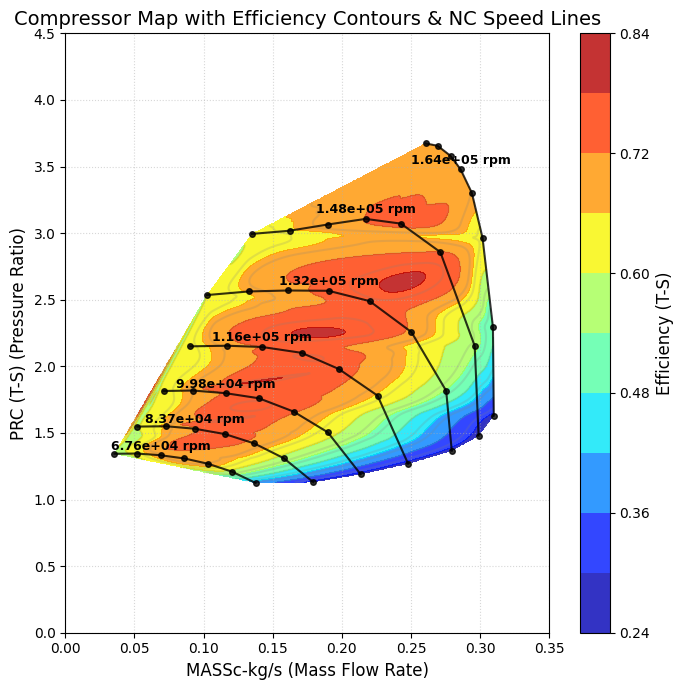

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# 1. 데이터 로드 및 전처리
df = pd.read_csv('Comp_Data.csv', skiprows=5)
df.columns = df.columns.str.strip()
data = df[['NC (rpm)', 'MASSc-kg/s', 'PRC (T-S)', 'Efficiency (T-S)']].dropna()

# 2. NC(회전수)별로 곡선을 구분하기 위한 그룹화
# NC 값이 미세하게 다를 수 있으므로, 연속된 유사 값들을 하나의 그룹으로 묶습니다.
data['NC_Group'] = (data['NC (rpm)'].diff().abs() > 1000).cumsum()

x = data['MASSc-kg/s'].values
y = data['PRC (T-S)'].values
z = data['Efficiency (T-S)'].values

# 3. 배경 컨투어 생성을 위한 그리드 보간
xi = np.linspace(x.min(), x.max(), 500)
yi = np.linspace(y.min(), y.max(), 500)
xi, yi = np.meshgrid(xi, yi)
# zi = griddata((x, y), z, (xi, yi), method='linear')
zi = griddata((x, y), z, (xi, yi), method='cubic')    # 수정 - 등고선 곡선 처리 (260115)

# 4. 시각화
plt.figure(figsize=(7, 7))     # 사이즈 조정 (260115)

# 배경: Efficiency 컨투어 (짙을수록 고효율)
contour = plt.contourf(xi, yi, zi, levels=8, cmap='jet', alpha=0.8)   # 레벨 작게 조정 (260115)
# 등고선 추가
plt.contour(xi, yi, zi, levels=16, alpha=0.2, colors='grey')          # 등고선 레벨 - contour 2배로 설정 (260115)

cbar = plt.colorbar(contour)
cbar.set_label('Efficiency (T-S)', fontsize=12)

# 각 NC 그룹별로 곡선 그리기 및 라벨 추가
for group_id, group_data in data.groupby('NC_Group'):
    # 유량(X축) 기준으로 정렬하여 선이 꼬이지 않게 함
    group_data = group_data.sort_values('MASSc-kg/s')
    
    gx = group_data['MASSc-kg/s']
    gy = group_data['PRC (T-S)']
    gnc_mean = group_data['NC (rpm)'].mean() # NC 평균값 계산
    
    # 검은색 선으로 포인트 연결
    plt.plot(gx, gy, color='black', linewidth=1.5, marker='o', markersize=4, alpha=0.8)
    
    # 곡선의 마지막 지점(보통 저유량/서지 라인 쪽)에 rpm 라벨 표시
    # label_x = gx.iloc[-1]
    # label_y = gy.iloc[-1]
    label_x = gx.iloc[-5]     # 라벨 위치 변경 (그래프 왼쪽으로 이동) (260115)
    label_y = gy.iloc[-5]     # 라벨 위치 변경 (그래프 왼쪽으로 이동) (260115)
    plt.text(label_x, label_y + 0.02, f"{int(gnc_mean):.2e} rpm",     # 회전 속도 - 유효숫자 소숫점 2자리까지 (:.2e) (260115)
             fontsize=9, fontweight='bold', va='bottom', ha='center')

plt.xlabel('MASSc-kg/s (Mass Flow Rate)', fontsize=12)
plt.ylabel('PRC (T-S) (Pressure Ratio)', fontsize=12)
plt.title('Compressor Map with Efficiency Contours & NC Speed Lines', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)

# Compressor map과 그래프 공간에서 패딩 추가 (260115)
plt.xticks(np.arange(0, 0.4, 0.05))
plt.yticks(np.arange(0, 5, 0.5))

plt.tight_layout()
plt.show()